# Baseline Model for Titer Prediction

Runs the baseline model comparison using the cleaned/feature-engineered per-experiment time series datasets

- Linear Regression
- Multiple Linear Regression (MLR) with top 5 features
- Multiple Linear Regression (MLR) with top 10 features
- Multiple Linear Regression (MLR) with all features
- Ridge regression (L2-regularized)
- PLS regression
- Random Forest
- Gradient Boosting
- XGBoost

In [1]:
import pathlib

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [2]:
DATA_DIR = "../data"
train_exp = pd.read_csv(f"{DATA_DIR}/train_exp_features.csv", index_col="Exp")

feature_cols = [c for c in train_exp.columns if c not in ("Y:Titer", "n_days")]

print("train_exp:", train_exp.shape)
print(f"Using {len(feature_cols)} non-redundant features")
train_exp.head()

train_exp: (100, 19)
Using 18 non-redundant features


,VCD_time_to_peak,Lysed_slope,VCD_auc,Lac_auc,Z:ExpDuration,FeedGlc_auc,FeedGln_slope,VCD_final,FeedGln_auc,Lac_slope,FeedGln_final,ph_shift_reached,pH_final,FeedGlc_final,temp_final,temp_shift_reached,Glc_final,Z:tempStart,Y:Titer
Exp,,,,,,,,,,,,,,,,,,,
Exp 1,10.0,0.022485,198.803887,40.956149,10.0,45.252525,0.247934,36.988184,54.545455,0.387198,0.000000,True,6.479798,0.000000,37.282828,False,14.657896,37.282828,2550.097032
Exp 2,6.0,0.018635,74.750902,52.328712,10.0,54.121212,0.317264,3.199769,66.308081,0.701286,6.979798,True,6.207071,5.696970,35.595960,True,44.011310,37.121212,1278.058508
Exp 3,9.0,0.003967,79.912784,30.101523,9.0,19.696970,0.921763,18.878325,47.075758,0.612346,7.242424,True,6.803030,3.030303,35.818182,True,9.393444,37.565657,1162.646534
Exp 4,8.0,0.006892,64.793778,33.968210,9.0,33.636364,0.663116,10.807090,51.287879,0.743174,6.838384,False,6.717172,4.484848,37.787879,False,23.473798,37.787879,1012.535606
Exp 5,8.0,0.004464,100.495435,30.108121,8.0,28.000000,0.934848,27.690723,34.277778,0.604946,6.232323,False,7.424242,5.090909,35.858586,True,12.257980,36.979798,1132.710237


## 1. Baseline modeling

With only 100 experiments and many of (collinear) engineered features, we here compare baseline regressors under repeated K-fold cross-validation on the train set.

In [3]:
X = train_exp[feature_cols].to_numpy()
y = train_exp["Y:Titer"].to_numpy()

# Top correlated features
_corr_sorted = (
    train_exp[feature_cols]
    .corrwith(train_exp["Y:Titer"])
    .abs()
    .sort_values(ascending=False)
)

best_5_features = _corr_sorted.head(5).index.tolist()
best_10_features = _corr_sorted.head(10).index.tolist()

X_top5 = train_exp[best_5_features].to_numpy()
X_top10 = train_exp[best_10_features].to_numpy()
X_best = X_top5[:, 0].reshape(-1, 1)
print(f"Top 5 features for MLR model: {best_5_features}")
print(f"Top 10 features for MLR model: {best_10_features}")

Top 5 features for MLR model: ['VCD_time_to_peak', 'Lysed_slope', 'VCD_auc', 'Lac_auc', 'Z:ExpDuration']
Top 10 features for MLR model: ['VCD_time_to_peak', 'Lysed_slope', 'VCD_auc', 'Lac_auc', 'Z:ExpDuration', 'FeedGlc_auc', 'FeedGln_slope', 'VCD_final', 'FeedGln_auc', 'Lac_slope']


In [4]:
models = {
    "LR": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X_best,
    ),
    "MLR_Top5": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X_top5,
    ),
    "MLR_Top10": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X_top10,
    ),
    "MLR": (
        Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        X,
    ),
    "Ridge": (
        Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
        X,
    ),
    "PLS_5": (
        Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", PLSRegression(n_components=5)),
            ]
        ),
        X,
    ),
    "RF": (
        RandomForestRegressor(n_estimators=300, max_depth=5, random_state=0),
        X,
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0
        ),
        X,
    ),
    "XGBoost": (
        XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0),
        X,
    ),
}

In [5]:
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)

results = []
for name, (model, X_model) in models.items():
    scores = cross_validate(
        model,
        X_model,
        y,
        cv=cv,
        scoring=[
            "r2",
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error",
        ],
    )
    rmse_mean = -scores["test_neg_root_mean_squared_error"].mean()
    results.append(
        {
            "model": name,
            "R2_mean": scores["test_r2"].mean(),
            "R2_std": scores["test_r2"].std(),
            "MAE_mean": -scores["test_neg_mean_absolute_error"].mean(),
            "RMSE_mean": rmse_mean,
            "RRMSE_mean": rmse_mean / y.mean(),
        }
    )

results_df = (
    pd.DataFrame(results).sort_values("R2_mean", ascending=False).reset_index(drop=True)
)
results_df

,model,R2_mean,R2_std,MAE_mean,RMSE_mean,RRMSE_mean
0,PLS_5,0.771381,0.151608,215.841743,323.595393,0.246172
1,Ridge,0.767947,0.162295,207.028124,328.776221,0.250114
2,MLR_Top5,0.731521,0.190896,229.866479,355.343634,0.270325
3,MLR,0.723801,0.185626,238.266877,357.851211,0.272232
4,RF,0.713515,0.136444,234.781302,376.477275,0.286402
5,GradientBoosting,0.704461,0.158679,223.960761,381.468959,0.290199
6,MLR_Top10,0.690601,0.299823,236.291755,369.052907,0.280754
7,XGBoost,0.648607,0.261109,242.394278,405.894077,0.308780
8,LR,0.454314,0.313005,350.415814,505.047981,0.384211


Top Choice: PLS with 5 components

- Highest Overall Accuracy: Achieves the best average fit ($R^2 = 0.7714$) and the lowest penalization for large errors ($\text{RMSE} = 323.60$, $\text{RRMSE} = 24.6%$).
- Ideal for bioprocess features: PLS projects collinear time-series summary features (AUCs, rates/slopes, etc.) into latent structures that maximize covariance with Y:Titer, making it robust against multicollinearity in small datasets ($N=100$).

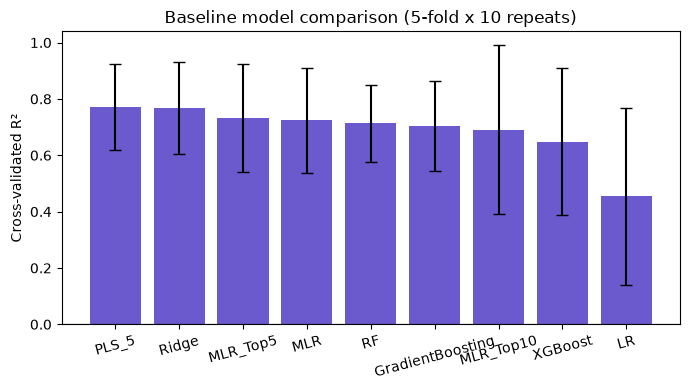

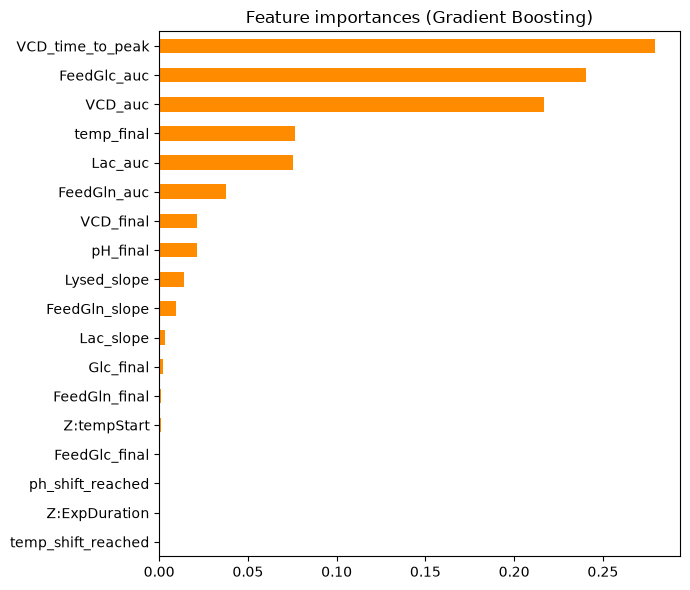

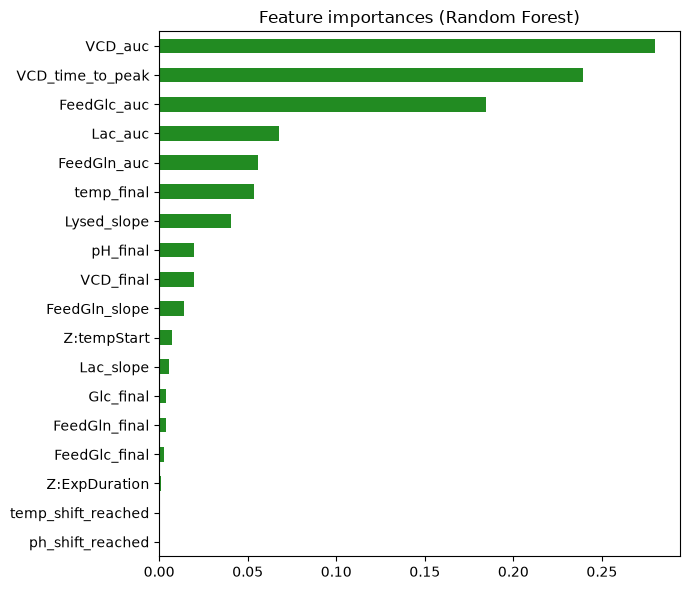

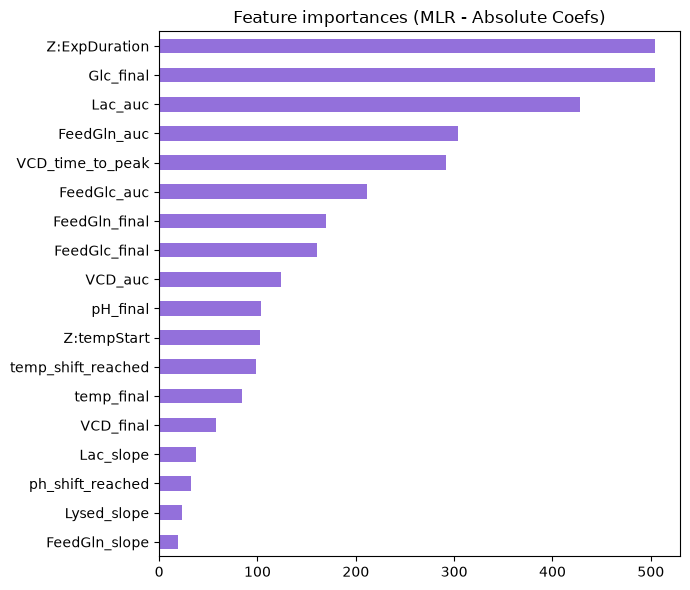

In [6]:
plt.figure(figsize=(7, 4))
plt.bar(
    results_df["model"],
    results_df["R2_mean"],
    yerr=results_df["R2_std"],
    capsize=4,
    color="slateblue",
)
plt.ylabel("Cross-validated R²")
plt.title("Baseline model comparison (5-fold x 10 repeats)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Feature importance from the best tree-based model for interpretability
best_tree = GradientBoostingRegressor(
    n_estimators=200, max_depth=2, learning_rate=0.05, random_state=0
).fit(X, y)
importances = pd.Series(best_tree.feature_importances_, index=feature_cols).sort_values(
    ascending=False
)

plt.figure(figsize=(7, 6))
importances[::-1].plot.barh(color="darkorange")
plt.title("Feature importances (Gradient Boosting)")
plt.tight_layout()
plt.show()

# Feature importance from Random Forest
rf_tree = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=0).fit(X, y)
rf_importances = pd.Series(
    rf_tree.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(7, 6))
rf_importances[::-1].plot.barh(color="forestgreen")
plt.title("Feature importances (Random Forest)")
plt.tight_layout()
plt.show()

# Feature importance from Multiple Linear Regression (MLR)
mlr_model = Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]).fit(
    X, y
)
mlr_importances = pd.Series(
    np.abs(mlr_model.named_steps["model"].coef_), index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(7, 6))
mlr_importances[::-1].plot.barh(color="mediumpurple")
plt.title("Feature importances (MLR - Absolute Coefs)")
plt.tight_layout()
plt.show()

In [7]:
# Train and save model
MODELS_DIR = pathlib.Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

for name, (model, X_model) in models.items():
    model.fit(X_model, y)
    filename = (
        MODELS_DIR
        / f"{name.replace(' ', '_').replace('(', '').replace(')', '')}.joblib"
    )
    joblib.dump(model, filename)